# EMS741 Few-Shot Segmentation: Reptile
Group 8: Timothy Lundberg, Oluwaniyi Victor Momoh, Kabisan Thayaparan

This notebook is formatted to run correctly on both JupyterHub and Colab by relying on environment variables for the dataset and importing all core functions from `core_methods.py`.

In [ ]:
# --- Setup: environment fixes and autoreload ---
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # Windows / OpenMP fix
print("KMP_DUPLICATE_LIB_OK =", os.environ.get("KMP_DUPLICATE_LIB_OK"))

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import zipfile, subprocess

!nvidia-smi -L || echo "No GPU visible"

KMP_DUPLICATE_LIB_OK = TRUE
GPU 0: NVIDIA A40 (UUID: GPU-258f158f-556e-619c-822d-349eda75d313)


## 1. Dataset Setup
Checks for an existing dataset at `EMS741_DATA_ROOT`. If not found, downloads and extracts 
it to the current working directory. No manual steps needed on Colab.

In [55]:


# If the dataset is already available on the cluster, set EMS741_DATA_ROOT
# before starting Jupyter. Otherwise, it will download into the CWD.
DATA_ROOT = None

if DATA_ROOT is None:
    env_root = os.environ.get("EMS741_DATA_ROOT")
    DATA_ROOT = Path(env_root) if env_root else Path.cwd()

def has_dataset(root: Path):
    return all((root / s).exists() for s in ["train", "val", "test"])

if not has_dataset(DATA_ROOT):
    print(f"Dataset not found in {DATA_ROOT.resolve()}")
    print("Downloading dataset to current working directory...")
    url = "https://zenodo.org/records/18745413/files/ems741_cw_data.zip?download=1"
    zip_path = Path("data.zip")
    if not zip_path.exists():
        subprocess.run(["wget", "-O", str(zip_path), url], check=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(Path.cwd())
    DATA_ROOT = Path.cwd()

print("DATA_ROOT:", DATA_ROOT.resolve())

DATA_ROOT: /home/jovyan/Git/QMUL-EMS741-Group-8


## 2. Imports
Downloads core_methods.py from GitHub if not already present (needed on Colab)

In [ ]:
import os, subprocess
from pathlib import Path

CORE_METHODS_URL = (
    "https://raw.githubusercontent.com/timfkl/QMUL-EMS741-Group-8/99da23456b2549dd9960958a9f9725251a4a9063/core_methods.py"
)

if not Path("core_methods.py").exists():
    print("Downloading core_methods.py...")
    subprocess.run(["wget", "-q", "-O", "core_methods.py", CORE_METHODS_URL], check=True)
    print("Done.")
else:
    print("core_methods.py already present.")

import torch
import numpy as np
import random

from core_methods import (
    UNet,
    SegDataset,
    FewShotEpisode,
    discover_tasks,
    reptile_meta_train,
    adapt_and_evaluate,
    unified_adapt_and_evaluate,
    bce_dice_loss,
    dice_score,
    DEFAULT_CONFIG,
)


core_methods.py already present.


## 3. Reproducibility & Device
Set `BASE_SEED` here to change the random seed for the entire run. Seeds used in our experiments: 42, 123, 7.

In [57]:
BASE_SEED = 42

from datetime import  datetime
RUN_ID = datetime.now().strftime("%y%m%d_%H%M")

# Set to True to skip meta-training and load a saved checkpoint instead
LOAD_FROM_CHECKPOINT = False
CHECKPOINT_TO_LOAD   = "results/metamodel_best-260329_0107.pt"

torch.manual_seed(BASE_SEED)
np.random.seed(BASE_SEED)
random.seed(BASE_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


## 4. Task Discovery
Scans `train/`, `val/`, and `test/` subdirectories and maps task names to their file paths.

In [58]:
train_tasks = discover_tasks(DATA_ROOT / "train")
val_tasks   = discover_tasks(DATA_ROOT / "val")
test_tasks  = discover_tasks(DATA_ROOT / "test")

print("Train tasks:", list(train_tasks.keys()))
print("Val tasks:",   list(val_tasks.keys()))
print("Test tasks:",  list(test_tasks.keys()))

Train tasks: ['task_2', 'task_3', 'task_5', 'task_7']
Val tasks: ['task_4', 'task_6']
Test tasks: ['task_1', 'task_8']


## 5. Reptile Meta-Training
Trains a shared UNet initialisation using the Reptile algorithm. The best checkpoint by 5-shot val Dice is saved automatically. Adjust `N_OUTER`, `K_INNER`, `INNER_LR`, and `META_LR` to change the training configuration.

In [59]:
# Meta-training config (Victor-like but shorter)
N_OUTER   = 8000
K_INNER   = 10
INNER_LR  = 3e-3
META_LR   = 0.01
VAL_EVERY = 200

if not LOAD_FROM_CHECKPOINT:
    print(f"Starting Reptile meta-training ({N_OUTER} outer, {K_INNER} inner steps)...")

    meta_model, meta_history, best_val, best_step, best_weights, metamodelbest_checkpoint = reptile_meta_train(
        train_tasks=train_tasks,
        val_tasks=val_tasks,
        n_outer=N_OUTER,
        k_inner=K_INNER,
        inner_lr=INNER_LR,
        meta_lr=META_LR,
        batch_size=4,
        val_every=VAL_EVERY,
        n_shot_val=DEFAULT_CONFIG["N_SHOT_VAL"],          # 5-shot val
        meta_lr_min_factor=DEFAULT_CONFIG["META_LR_MIN_FACTOR"],
        use_val_ema=DEFAULT_CONFIG["USE_VAL_DICE_EMA"],   # False by default
        ema_alpha=DEFAULT_CONFIG["VAL_DICE_EMA_ALPHA"],
        checkpoint_best=DEFAULT_CONFIG["CHECKPOINT_BEST"],
        checkpoint_path=f"metamodel_best-{RUN_ID}.pt",
    )

    torch.save(meta_model.state_dict(), f"meta_model_{N_OUTER}_outer.pth")
    print(f"Meta-model saved to meta_model_{N_OUTER}_outer.pth")

## 6. Restore Best Checkpoint
Loads the best weights saved during meta-training. Replace `metamodelbest_checkpoint` with a filename string to load a specific saved run instead.

In [ ]:
if LOAD_FROM_CHECKPOINT:
    import json
    # Find the summary JSON matching your run
    summary_path = "temp/summary_EMS741_20260329_010700.json"

    with open(summary_path) as f:
        summary = json.load(f)

    best_val  = summary["metamodel_best_dice"]
    best_step = summary["metamodel_best_step"]
    BASE_SEED = summary["SEED"]
    N_OUTER   = summary["n_outer"]
    K_INNER   = summary["k_inner"]
    INNER_LR  = summary["inner_lr"]
    META_LR   = summary["meta_lr"]

    metamodelbest_checkpoint = "results/metamodel_best-260329_0107.pt"

    meta_history = {"outer_step": [], "val_dice": [], "meta_loss": [], "meta_lr": []}

    print(f"Loaded summary: seed={BASE_SEED}, best_val={best_val:.4f}, best_step={best_step}")
    print(f"Checkpoint: {metamodelbest_checkpoint}")

Loaded summary: seed=42, best_val=0.2140, best_step=7600
Checkpoint: results/metamodel_best-260329_0107.pt


In [61]:
try:
    meta_model = UNet(norm=DEFAULT_CONFIG["NORM"]).to(DEVICE)
    meta_model.load_state_dict(torch.load(metamodelbest_checkpoint, map_location=DEVICE)) # or replace metamodelbest_checkpoint with file name
    print(f"Restored best weights from step {best_step}  (val Dice {best_val:.4f})")
    meta_model.eval()
except FileNotFoundError as e:
    print(f"Checkpoint load failed:{e}")

Restored best weights from step 7600  (val Dice 0.2140)


## 7. Few-Shot Evaluation
Evaluates Reptile (adapted from meta-init) against a from-scratch baseline UNet across 1/3/5-shot settings, repeated over `N_REPEATS` seeds on all test tasks.

In [62]:
N_SHOTS         = [1, 3, 5]
ADAPT_STEPS     = DEFAULT_CONFIG["ADAPT_STEPS"]       # 30
BASELINE_EPOCHS = DEFAULT_CONFIG["BASELINE_EPOCHS"]   # 30
N_REPEATS       = 3

results = {}

for n_shot in N_SHOTS:
    reptilescores = []
    baselinescores = []
    print(f"\n=== {n_shot}-shot evaluation ===")
    for seed in range(N_REPEATS):
        print(f" seed {seed}")
        task_names = list(test_tasks.keys())
        total_tasks = len(task_names)
        rtasks, btasks = [], []

        for i, task_name in enumerate(task_names, start=1):
            task_dict = test_tasks[task_name]

            # Reptile: adapt pre-trained meta_model
            rd, _, _ = adapt_and_evaluate(
                meta_model,
                task_dict,
                n_shot=n_shot,
                adapt_steps=ADAPT_STEPS,
                adapt_lr=DEFAULT_CONFIG["ADAPT_LR"],   # 1e-3
                seed=seed,
            )

            # Baseline: scratch UNet with same inner loop & cosine scheduler
            base = UNet(norm=DEFAULT_CONFIG["NORM"]).to(DEVICE)
            bd, _, _ = unified_adapt_and_evaluate(
                base,
                task_dict,
                n_shot=n_shot,
                epochs=BASELINE_EPOCHS,                # inner steps
                lr=DEFAULT_CONFIG["BASELINE_LR"],      # 1e-3
                seed=seed,
                use_scheduler=True,                    # cosine LR like Victor
                optimizer_cls=torch.optim.Adam,
            )

            print(
                f" [{i}/{total_tasks}] Task {task_name} | "
                f"Reptile: {rd:.4f} | Baseline: {bd:.4f}"
            )
            rtasks.append(rd)
            btasks.append(bd)

        reptilescores.append(float(np.mean(rtasks)))
        baselinescores.append(float(np.mean(btasks)))

    results[n_shot] = {"reptile": reptilescores, "baseline": baselinescores}


=== 1-shot evaluation ===
 seed 0
 [1/2] Task task_1 | Reptile: 0.3707 | Baseline: 0.2008
 [2/2] Task task_8 | Reptile: 0.0887 | Baseline: 0.0197
 seed 1
 [1/2] Task task_1 | Reptile: 0.3473 | Baseline: 0.2879
 [2/2] Task task_8 | Reptile: 0.0037 | Baseline: 0.0178
 seed 2
 [1/2] Task task_1 | Reptile: 0.3466 | Baseline: 0.2541
 [2/2] Task task_8 | Reptile: 0.0587 | Baseline: 0.0002

=== 3-shot evaluation ===
 seed 0
 [1/2] Task task_1 | Reptile: 0.4303 | Baseline: 0.2502
 [2/2] Task task_8 | Reptile: 0.0692 | Baseline: 0.0188
 seed 1
 [1/2] Task task_1 | Reptile: 0.3672 | Baseline: 0.2801
 [2/2] Task task_8 | Reptile: 0.0848 | Baseline: 0.0314
 seed 2
 [1/2] Task task_1 | Reptile: 0.3931 | Baseline: 0.3329
 [2/2] Task task_8 | Reptile: 0.0062 | Baseline: 0.0002

=== 5-shot evaluation ===
 seed 0
 [1/2] Task task_1 | Reptile: 0.3454 | Baseline: 0.1838
 [2/2] Task task_8 | Reptile: 0.1078 | Baseline: 0.0251
 seed 1
 [1/2] Task task_1 | Reptile: 0.3452 | Baseline: 0.3196
 [2/2] Task tas

# Research Question data processing
- RQ1: How does segmentation performance change as the number of available 
annotated examples increases?
For example, compare performance for 1-shot, 3-shot, and 5-shot adaptation.
- RQ2: Are some anatomical structures easier to adapt to than others?
Discuss differences in performance across structures, and relate these to 
factors such as size, shape variability, or image contrast.
- RQ3: How stable are the results across different choices of available few shot 
annotated examples?


In [70]:
# ── Per-structure analysis (RQ2) — Reptile + Baseline ──
per_structure = {}

for n_shot in N_SHOTS:
    for seed in range(N_REPEATS):
        for task_name, task_dict in test_tasks.items():
            if task_name not in per_structure:
                per_structure[task_name] = {}
            if n_shot not in per_structure[task_name]:
                per_structure[task_name][n_shot] = {"reptile": [], "baseline": []}

            # Reptile
            rd, _, _ = adapt_and_evaluate(
                meta_model, task_dict,
                n_shot=n_shot,
                adapt_steps=ADAPT_STEPS,
                adapt_lr=DEFAULT_CONFIG["ADAPT_LR"],
                seed=seed,
            )

            # Baseline
            base = UNet(norm=DEFAULT_CONFIG["NORM"]).to(DEVICE)
            bd, _, _ = unified_adapt_and_evaluate(
                base, task_dict,
                n_shot=n_shot,
                epochs=BASELINE_EPOCHS,
                lr=DEFAULT_CONFIG["BASELINE_LR"],
                seed=seed,
                use_scheduler=True,
                optimizer_cls=torch.optim.Adam,
            )

            per_structure[task_name][n_shot]["reptile"].append(rd)
            per_structure[task_name][n_shot]["baseline"].append(bd)
            print(f"  {task_name} | {n_shot}-shot | seed {seed} | Reptile {rd:.4f} | Baseline {bd:.4f}")

# Print table
print(f"\n{'Task':<12} {'Shot':<6} {'Reptile':>10} {'Baseline':>10}")
for task_name in sorted(per_structure):
    for n_shot in N_SHOTS:
        r = np.mean(per_structure[task_name][n_shot]["reptile"])
        b = np.mean(per_structure[task_name][n_shot]["baseline"])
        print(f"{task_name:<12} {n_shot:<6} {r:>10.4f} {b:>10.4f}")

  task_1 | 1-shot | seed 0 | Reptile 0.3682 | Baseline 0.2034
  task_8 | 1-shot | seed 0 | Reptile 0.0895 | Baseline 0.0198
  task_1 | 1-shot | seed 1 | Reptile 0.3469 | Baseline 0.2902
  task_8 | 1-shot | seed 1 | Reptile 0.0037 | Baseline 0.0178
  task_1 | 1-shot | seed 2 | Reptile 0.3635 | Baseline 0.2541
  task_8 | 1-shot | seed 2 | Reptile 0.0590 | Baseline 0.0002
  task_1 | 3-shot | seed 0 | Reptile 0.4303 | Baseline 0.2502
  task_8 | 3-shot | seed 0 | Reptile 0.0694 | Baseline 0.0188
  task_1 | 3-shot | seed 1 | Reptile 0.3697 | Baseline 0.2767
  task_8 | 3-shot | seed 1 | Reptile 0.0713 | Baseline 0.0314
  task_1 | 3-shot | seed 2 | Reptile 0.3981 | Baseline 0.3318
  task_8 | 3-shot | seed 2 | Reptile 0.0064 | Baseline 0.0002
  task_1 | 5-shot | seed 0 | Reptile 0.3454 | Baseline 0.1838
  task_8 | 5-shot | seed 0 | Reptile 0.1068 | Baseline 0.0251
  task_1 | 5-shot | seed 1 | Reptile 0.3455 | Baseline 0.3196
  task_8 | 5-shot | seed 1 | Reptile 0.0775 | Baseline 0.0583
  task_1

In [71]:
# RQ2 - Save to CSV for the report
import csv
import numpy as np

with open("per_structure_results.csv", "w", newline="") as f:
    writer = csv.writer(f)
    # Header
    writer.writerow([
        "task",
        "1_shot_reptile_mean", "1_shot_reptile_std",
        "3_shot_reptile_mean", "3_shot_reptile_std",
        "5_shot_reptile_mean", "5_shot_reptile_std",
        "1_shot_baseline_mean", "1_shot_baseline_std",
        "3_shot_baseline_mean", "3_shot_baseline_std",
        "5_shot_baseline_mean", "5_shot_baseline_std",
    ])
    for task_name in sorted(per_structure):
        row = [task_name]
        for n_shot in N_SHOTS:
            r = per_structure[task_name][n_shot]["reptile"]
            row += [f"{np.mean(r):.4f}", f"{np.std(r):.4f}"]
        for n_shot in N_SHOTS:
            b = per_structure[task_name][n_shot]["baseline"]
            row += [f"{np.mean(b):.4f}", f"{np.std(b):.4f}"]
        writer.writerow(row)

print("Saved per_structure_results.csv")

Saved per_structure_results.csv


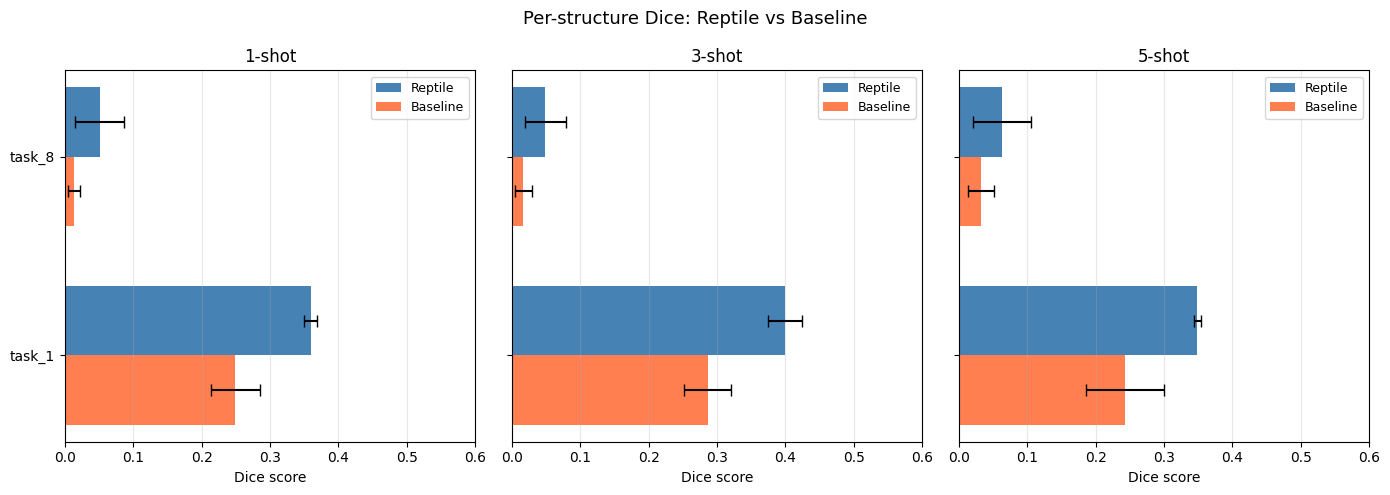

In [72]:
#RQ2 - Plot per-structure bar chart
fig, axes = plt.subplots(1, len(N_SHOTS), figsize=(14, 5), sharey=True)
task_names = sorted(per_structure.keys())
x = np.arange(len(task_names))
width = 0.35

for ax, n_shot in zip(axes, N_SHOTS):
    r_means = [np.mean(per_structure[t][n_shot]["reptile"])  for t in task_names]
    r_stds  = [np.std(per_structure[t][n_shot]["reptile"])   for t in task_names]
    b_means = [np.mean(per_structure[t][n_shot]["baseline"]) for t in task_names]
    b_stds  = [np.std(per_structure[t][n_shot]["baseline"])  for t in task_names]

    ax.barh(x + width/2, r_means, width, xerr=r_stds, capsize=4,
            color="steelblue", label="Reptile")
    ax.barh(x - width/2, b_means, width, xerr=b_stds, capsize=4,
            color="coral", label="Baseline")

    ax.set_title(f"{n_shot}-shot")
    ax.set_xlabel("Dice score")
    ax.set_yticks(x)
    ax.set_yticklabels(task_names)
    ax.set_xlim(0, 0.6)
    ax.grid(True, alpha=0.3, axis="x")
    ax.legend(fontsize=9)

fig.suptitle("Per-structure Dice: Reptile vs Baseline", fontsize=13)
plt.tight_layout()
plt.savefig("per_structure_results.png", dpi=150)
plt.show()

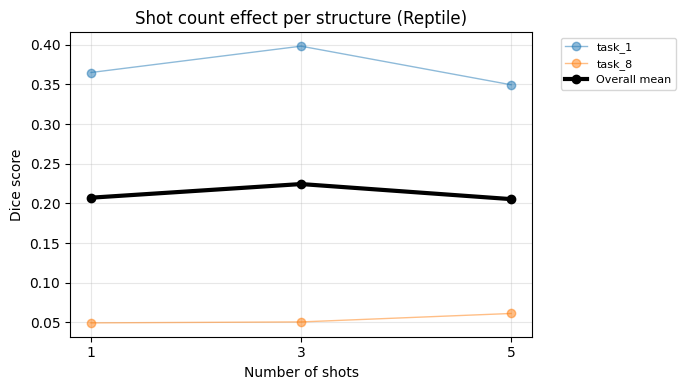

In [68]:
#RQ1 — Shot count trend plot (highlights 3>5 anomaly)
fig, ax = plt.subplots(figsize=(7, 4))
for task_name in sorted(per_structure.keys()):
    means = [np.mean(per_structure[task_name][s]) for s in N_SHOTS]
    ax.plot(N_SHOTS, means, marker="o", alpha=0.5, linewidth=1, label=task_name)

# Overall mean line
overall_means = [np.mean([np.mean(per_structure[t][s]) for t in task_names]) for s in N_SHOTS]
ax.plot(N_SHOTS, overall_means, marker="o", linewidth=3,
        color="black", label="Overall mean", zorder=5)

ax.set_xlabel("Number of shots")
ax.set_ylabel("Dice score")
ax.set_title("Shot count effect per structure (Reptile)")
ax.set_xticks(N_SHOTS)
ax.legend(fontsize=8, bbox_to_anchor=(1.05, 1))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("shot_count_per_structure.png", dpi=150)
plt.show()

In [75]:
#RQ2: Analyse structure properties from the full task datasets
from PIL import Image as PILImage
structure_stats = {}

for task_name, task_dict in test_tasks.items():
    fg_ratios = []
    for mask_path in task_dict["masks"]:
        mask = np.array(PILImage.open(mask_path).convert("L"))
        mask_bin = (mask > 127).astype(np.uint8)
        fg_ratios.append(mask_bin.sum() / mask_bin.size)
    
    structure_stats[task_name] = {
        "mean_fg_ratio": np.mean(fg_ratios),   # how large the structure is
        "std_fg_ratio":  np.std(fg_ratios),    # shape/size variability across slices
        "n_slices":      len(fg_ratios),
    }
    print(
        f"{task_name}: mean foreground={np.mean(fg_ratios)*100:.2f}%  "
        f"std={np.std(fg_ratios)*100:.2f}%  slices={len(fg_ratios)}"
    )

task_1: mean foreground=6.22%  std=5.66%  slices=775
task_8: mean foreground=0.63%  std=0.51%  slices=648


In [76]:
#RQ2: Compute image contrast near the mask
from PIL import Image as PILImage

for task_name, task_dict in test_tasks.items():
    contrasts = []
    for img_path, mask_path in zip(task_dict["images"], task_dict["masks"]):
        img  = np.array(PILImage.open(img_path).convert("L")).astype(np.float32) / 255.0
        mask = (np.array(PILImage.open(mask_path).convert("L")) > 127)
        
        if mask.sum() < 10:  # skip nearly empty slices
            continue
        
        fg_mean = img[mask].mean()
        bg_mean = img[~mask].mean()
        contrasts.append(abs(fg_mean - bg_mean))
    
    structure_stats[task_name]["mean_contrast"] = np.mean(contrasts)
    print(f"{task_name}: mean contrast={np.mean(contrasts):.4f}")

task_1: mean contrast=0.2873
task_8: mean contrast=0.1037


In [69]:
#RQ3 — Seed stability summary (uses existing results dict)
print("Seed stability (mean Dice across all tasks and shots):")
seeds = [42, 123, 7]
seed_results = {
    42:  [0.2351, 0.1753, 0.2106, 0.2490, 0.2212, 0.2007, 0.2265, 0.2112, 0.1821],
    123: [0.2124, 0.1809, 0.1204, 0.1888, 0.2223, 0.1709, 0.1835, 0.1753, 0.1435],
    7:   [0.2324, 0.2223, 0.1420, 0.2226, 0.2240, 0.1781, 0.1718, 0.1819, 0.1632],
}
for seed, vals in seed_results.items():
    print(f"  Seed {seed:>3}: mean={np.mean(vals):.4f}  std={np.std(vals):.4f}  min={np.min(vals):.4f}  max={np.max(vals):.4f}")

Seed stability (mean Dice across all tasks and shots):
  Seed  42: mean=0.2124  std=0.0225  min=0.1753  max=0.2490
  Seed 123: mean=0.1776  std=0.0296  min=0.1204  max=0.2223
  Seed   7: mean=0.1931  std=0.0308  min=0.1420  max=0.2324


## 8. Training Curves
Plots validation Dice over outer steps and meta-LR decay. Saved as `meta_training_val_dice.png` and `meta_training_meta_lr.png`.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1) Val Dice over outer steps
if meta_history["outer_step"]:
    plt.figure(figsize=(7, 4))
    plt.plot(meta_history["outer_step"], meta_history["val_dice"],
             marker="o", linewidth=2, color="steelblue")
    plt.xlabel("Outer step")
    plt.ylabel("Val Dice (5-shot)")
    plt.title("Reptile meta-training: validation Dice")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("meta_training_val_dice.png", dpi=150)
    plt.show()

# 2) Meta-LR decay plot
if "meta_lr" in meta_history and meta_history["meta_lr"]:
    plt.figure(figsize=(7, 4))
    plt.plot(meta_history["meta_lr"])
    plt.xlabel("Outer iteration")
    plt.ylabel("Meta learning rate")
    plt.title("Reptile meta-training: decaying meta-LR")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("meta_training_meta_lr.png", dpi=150)
    plt.show()

## 9. Qualitative Visualisation
Generates side-by-side panels of MR image, ground truth, Reptile prediction, and baseline prediction for each test task at 5-shot.

In [ ]:
def qualitative_panel(meta_model, task_dict, task_name,
                      n_shot=5, adapt_steps=20, seed=BASE_SEED, n_cols=4):
    """
    Show: image | GT | Reptile prediction | Baseline prediction (for same query).
    """
    r_dice, adapted_meta, episode = adapt_and_evaluate(
        meta_model, task_dict,
        n_shot=n_shot,
        adapt_steps=adapt_steps,
        adapt_lr=1e-3,
        seed=seed,
    )

    base = UNet().to(DEVICE)
    b_dice, adapted_base, _ = unified_adapt_and_evaluate(
        base,
        task_dict,
        n_shot=n_shot,
        epochs=20,
        lr=1e-3,
        seed=seed,
    )

    q_loader = episode.query_loader(batch_size=n_cols)
    # 1. Filter query slices (NEW)
    all_imgs, all_masks = [], []
    for imgs_b, masks_b in q_loader:
        for i in range(imgs_b.shape[0]):
            if masks_b[i].sum() > 0:
                all_imgs.append(imgs_b[i])
                all_masks.append(masks_b[i])
        if len(all_imgs) >= n_cols:
            break

    if len(all_imgs) == 0:
        print(f"[{task_name}] No query images with foreground masks available.")
        return

    imgs_b  = torch.stack(all_imgs[:n_cols]).to(DEVICE)
    masks_b = torch.stack(all_masks[:n_cols]).to(DEVICE)

    # 2. Run inference (KEEP UNCHANGED)
    adapted_meta.eval()
    adapted_base.eval()
    with torch.no_grad():
        preds_r = adapted_meta(imgs_b).cpu().numpy()
        preds_b = adapted_base(imgs_b).cpu().numpy()
        imgs_np = imgs_b.cpu().numpy()
        masks_np = masks_b.cpu().numpy()

    n = min(n_cols, imgs_np.shape[0])
    fig, axes = plt.subplots(4, n, figsize=(3 * n, 10))
    fig.suptitle(
        f"Task {task_name} | {n_shot}-shot "
        f"| Reptile Dice {r_dice:.3f} | Baseline Dice {b_dice:.3f}",
        fontsize=13,
    )

    row_labels = ["MR image", "Ground truth", "Reptile prediction", "Baseline prediction"]
    for row, label in enumerate(row_labels):
        axes[row, 0].set_ylabel(label, fontsize=11)

    for col in range(n):
        axes[0, col].imshow(imgs_np[col, 0], cmap="gray")
        axes[0, col].set_title(f"Query {col+1}", fontsize=10)
        axes[0, col].axis("off")

        axes[1, col].imshow(masks_np[col, 0] * 255, cmap="gray", vmin=0, vmax=255)
        axes[1, col].axis("off")

        axes[2, col].imshow(preds_r[col, 0], cmap="hot", vmin=0, vmax=1)
        axes[2, col].axis("off")

        axes[3, col].imshow(preds_b[col, 0], cmap="hot", vmin=0, vmax=1)
        axes[3, col].axis("off")

    plt.tight_layout()
    out_name = f"qualitative_{task_name}_nshot{n_shot}.png"
    plt.savefig(out_name, dpi=150)
    plt.show()
    print(f"Saved {out_name}")


# Generate qualitative panels for all test tasks at 5-shot
for t_name, t_dict in test_tasks.items():
    qualitative_panel(meta_model, t_dict, t_name, n_shot=5, adapt_steps=20)

## 10. Results Plot
Error bar plot of mean ± std Dice across repeat seeds for Reptile vs baseline. Saved as `few_shot_results.png`.

In [ ]:
shots = sorted(results.keys())
rmeans = [np.mean(results[s]["reptile"]) for s in shots]
rstds  = [np.std(results[s]["reptile"])  for s in shots]
bmeans = [np.mean(results[s]["baseline"]) for s in shots]
bstds  = [np.std(results[s]["baseline"])  for s in shots]

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(
    shots, rmeans, yerr=rstds,
    marker="o", linewidth=2, capsize=5,
    label="Reptile meta", color="steelblue",
)
ax.errorbar(
    shots, bmeans, yerr=bstds,
    marker="s", linewidth=2, capsize=5,
    linestyle="--",
    label="Baseline scratch", color="coral",
)
ax.set_xlabel("Number of shots (support examples)", fontsize=12)
ax.set_ylabel("Dice score", fontsize=12)
ax.set_title("Few-shot segmentation: Reptile vs baseline", fontsize=13)
ax.set_xticks(shots)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("few_shot_results.png", dpi=150)
plt.show()

## 11. Export Results
Bundles all outputs into a timestamped `.zip` in `results/`. The filename encodes seed, iterations, adapt steps, and best Dice for easy identification.

In [ ]:
import os
import json
import zipfile
from datetime import datetime

os.makedirs("results", exist_ok=True)
os.makedirs("temp", exist_ok=True)  # for any display-only images if needed

# Compute max Dice across all runs for naming
all_dice = []
for n_shot, vals in results.items():
    all_dice.extend(vals["reptile"])
    all_dice.extend(vals["baseline"])
max_dice = best_val if all_dice else 0.0

stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
zip_name = f"G8_BaseRepCompare_Seed{BASE_SEED}_{N_OUTER}iters_{ADAPT_STEPS}steps_{max_dice:.4f}dice_{stamp}.zip"
zip_path = os.path.join("results", zip_name)

summary = {
    "SEED": BASE_SEED,
    "n_outer": N_OUTER,
    "k_inner": K_INNER,
    "inner_lr": INNER_LR,
    "meta_lr": META_LR,
    "adapt_steps": ADAPT_STEPS,
    "baseline_epochs": BASELINE_EPOCHS,
    "device": DEVICE,
    "metamodel_best_step": best_step,
    "metamodel_best_dice": best_val,
    "results": results,
}

summary_name = f"summary_EMS741_{stamp}.json"
summary_path = os.path.join("temp", summary_name)
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

files_to_pack = [
    "meta_model.pth",
    "meta_training_val_dice.png",
    "few_shot_results.png",
    "few_shot_summary.csv",
    "meta_training_meta_lr.png",
    summary_path,
    metamodelbest_checkpoint,
]

# Optional: add qualitative panels if they exist
for fname in os.listdir("."):
    if fname.startswith("qualitative_") and fname.endswith(".png"):
        files_to_pack.append(os.path.join(".", fname))

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for f in files_to_pack:
        if os.path.exists(f):
            # store without leading ./ or temp/
            arcname = os.path.basename(f)
            z.write(f, arcname)

print("Created", zip_path)